# PDL Challenge 3: NLP with CNN, RNN, and GRU

Before running on Colab, go to **Runtime > Change runtime type** and select **GPU** (a T4 is enough), then use **Runtime > Run all** to run the notebook from top to bottom.
The dataset is downloaded automatically by `imdb.load_data`, so there is no need to mount Google Drive.

In [1]:
#Setup
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers

print('TensorFlow:', tf.__version__, '| Keras:', keras.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

#Fix the random seed so results are reproducible
keras.utils.set_random_seed(42)

#Maximum number of training epochs (with EarlyStopping: stop early if val_loss does not improve for 2 epochs)
EPOCHS = 8

TensorFlow: 2.20.0 | Keras: 3.13.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
#Task description
#build models that can accurately classify a review’s sentiment as positive or negative based on its content.
#Use diffenent learnin artchitectures and compare the results such as RNN, CNN, GRU

In [3]:
#Load the Data
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
import numpy as np
import pickle

# Load the IMDB dataset, limiting the vocabulary to 5000 words
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=5000)
#num_words keeps only the 5000 most frequent words; rarer words are dropped

# Save the data to a pkl file
with open('imdb_mini.pkl', 'wb') as f:
    pickle.dump((X_train, y_train, X_test, y_test), f)

print("IMDB dataset saved to imdb_mini.pkl.")
print("Number of training samples:", len(X_train))
print("Number of test samples:", len(X_test))

# 0 is a negative review, 1 is a positive review

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
IMDB dataset saved to imdb_mini.pkl.
Number of training samples: 25000
Number of test samples: 25000


In [4]:
#Review Tokenization and Padding
from tensorflow.keras.preprocessing.sequence import pad_sequences

#Set the maximum review length
#Make every review the same length: shorter ones are padded with 0, longer ones are truncated
max_length = 500

#Pad sequence
X_train_padded = pad_sequences(X_train, maxlen=max_length, padding = 'post')
X_test_padded = pad_sequences(X_test, maxlen=max_length, padding = 'post')

In [5]:
#Example of a processed review
print('Review ( Tokenized )')
print(X_train_padded[0])

#Corresponding label
print('Label')
print(y_train[0])

Review ( Tokenized )
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17  515   17   12   16
  626   18    2    5   62  386   12    8  316    8  106    5    4 2223
    2   16  480   66 3785   33    4  130   12   16   38  619    5   25
  124   51   36  135   48   25 1415   33    6   22   12  215   28   77
   52    5   14  407   16   82    2    8    4  107  117    2   15  256
    4    2    7 3766    5  723   36   71   43  530  476   26  400  317
   46    7    4    2 1029   13  104   88    4  381   15  297   98   32
 2071   56   26  141    6  194    2   18    4  226   22   21  134  476
   26  480    5  144   30    2   18   51   36   28  224 

In [6]:
#Mapping Words to Indices
from tensorflow.keras.datasets import imdb

#Retrieve the word index
word_index = imdb.get_word_index()

#Adjust the index
word_index = {k: (v+3) for k, v in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2
#Shift the indices to make room for the special tokens

#Reverse mapping from indices to words
index_word = {i: word for word,i in word_index.items()}

#Decode the first review
decoded_review = ' '.join([index_word.get(i,'?') for i in X_train [0]])
print('Review(Decoded)')
print(decoded_review)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Review(Decoded)
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly <UNK> was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little <UNK> that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big <UNK> for the whole film

In [7]:
#Segementing the Dataset
#Define the threshold
threshold_length = 100

idx_short = [i for i, review in enumerate(X_train) if len(review) <= threshold_length]
idx_long = [i for i, review in enumerate(X_train) if len(review) > threshold_length]

In [8]:
#Prepare the short and long subsets
X_short = [X_train[i] for i in idx_short]
y_short = [y_train[i] for i in idx_short]

X_long = [X_train[i] for i in idx_long]
y_long = [y_train[i] for i in idx_long]

#Pad the sequences
X_short_padded = pad_sequences(X_short, maxlen=max_length, padding='post')
X_long_padded = pad_sequences(X_long, maxlen=max_length, padding='post')

In [9]:
#Print the number of data for X_short and X_long and their corresponding labels
print('Number of short reviews:', len(X_short))
print('Number of long reviews:', len(X_long))
print('Number of short labels:', len(y_short))
print('Number of long labels:', len(y_long))

Number of short reviews: 2822
Number of long reviews: 22178
Number of short labels: 2822
Number of long labels: 22178


In [10]:
#print the integer sequence length of X_short_padded
print('Short review length:', len(X_short_padded[0]))
print('Long review length:', len(X_long_padded[0]))
print('Label:', y_short[0])
print('Label:', y_long[0])

Short review length: 500
Long review length: 500
Label: 0
Label: 1


In [11]:
#Check for the short review
decoded_review = ' '.join([index_word.get(i,'?') for i in X_short [0]])
print('Review(Decoded)')
print(decoded_review)

Review(Decoded)
<START> begins better than it ends funny that the russian <UNK> crew <UNK> all other actors it's like those scenes where documentary shots br br spoiler part the message <UNK> was contrary to the whole story it just does not <UNK> br br


In [12]:
#Check for the long review
decoded_review = ' '.join([index_word.get(i,'?') for i in X_long [0]])
print('Review(Decoded)')
print(decoded_review)

Review(Decoded)
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly <UNK> was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little <UNK> that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big <UNK> for the whole film but these children are amazing and should be <UN

In [13]:
#Convert to numpy arrays, and split the test set into short and long reviews with the same threshold
#test_lengths holds the original (unpadded) length of each test review, used later for the per-length analysis
X_short_padded = np.array(X_short_padded)
y_short = np.array(y_short)
X_long_padded = np.array(X_long_padded)
y_long = np.array(y_long)
X_test_padded = np.array(X_test_padded)
y_test = np.array(y_test)

test_lengths = np.array([len(review) for review in X_test])
idx_test_short = np.where(test_lengths <= threshold_length)[0]
idx_test_long = np.where(test_lengths > threshold_length)[0]

print('Short test reviews:', len(idx_test_short))
print('Long test reviews:', len(idx_test_long))

Short test reviews: 3012
Long test reviews: 21988


In [14]:
#CNN Model training for all reviews
#Keras 3 (the version on Colab) removed the input_length argument of Embedding, so keras.Input sets the input length instead
model = keras.Sequential([
    keras.Input(shape=(max_length,)),
    layers.Embedding(5000, 100),
    layers.Conv1D(256, 3, padding='valid', activation='relu'),
    layers.GlobalMaxPooling1D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])

#Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#Model Summary
model.summary()

#Train the model
model.fit(X_train_padded, y_train, epochs=5, batch_size=32, validation_data=(X_test_padded, y_test))

#Evaluate the model
loss, accuracy = model.evaluate(X_test_padded, y_test)
print('Test Accuracy:', accuracy)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 100)       │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 498, 256)       │        77,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 610,081 (2.33 MB)

 Trainable params: 610,081 (2.33 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.8296 - loss: 0.3644 - val_accuracy: 0.8912 - val_loss: 0.2630
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9322 - loss: 0.1793 - val_accuracy: 0.8810 - val_loss: 0.3117
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9720 - loss: 0.0860 - val_accuracy: 0.8849 - val_loss: 0.3818
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9764 - loss: 0.0643 - val_accuracy: 0.8589 - val_loss: 0.4907
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9778 - loss: 0.0592 - val_accuracy: 0.8579 - val_loss: 0.5775
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8579 - loss: 0.5775
Test Accuracy: 0.8579199910163879


## Shared utilities

**How the neuron budget K = 10,000 is counted:** the number of trainable parameters outside the Embedding layer is kept at about 10k.
The Embedding layer (5000 x 32 = 160k) is identical in every model, so it is not counted. This keeps the capacity of the CNN, RNN, GRU and LSTM comparable, so differences come mainly from the architecture itself.

In [15]:
vocabulary_size = 5000
EMBED_DIM = 32
K = 10000

def count_budget(model):
    """Return the number of trainable parameters outside the Embedding layer"""
    return sum(int(np.prod(w.shape))
               for layer in model.layers if not isinstance(layer, layers.Embedding)
               for w in layer.trainable_weights)

def train_and_evaluate(name, model, X, y, X_eval, y_eval, lr=1e-3, batch_size=64, clipnorm=None, epochs=None):
    """Train the model, evaluate it on X_eval, and return the history and results"""
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm),
                  loss='binary_crossentropy', metrics=['accuracy'])
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    start = time.time()
    history = model.fit(X, y, epochs=epochs or EPOCHS, batch_size=batch_size, validation_split=0.2,
                        callbacks=[early_stop], verbose=2)
    train_time = time.time() - start
    loss, accuracy = model.evaluate(X_eval, y_eval, verbose=0)
    n_epochs = len(history.history['loss'])
    result = {'loss': loss, 'accuracy': accuracy, 'params': count_budget(model),
              'train_time': train_time, 'epochs': n_epochs, 'time_per_epoch': train_time / n_epochs}
    print(f"{name}: test acc={accuracy:.4f}, test loss={loss:.4f}, params={result['params']} (K={K}), "
          f"time={train_time:.1f}s ({result['time_per_epoch']:.1f}s/epoch)")
    return history, result

def plot_loss(histories, title):
    """Plot the train loss (solid) and val loss (dashed) of each model"""
    plt.figure(figsize=(7, 4))
    for name, history in histories.items():
        line, = plt.plot(history.history['loss'], label=f'{name} train')
        plt.plot(history.history['val_loss'], '--', color=line.get_color(), label=f'{name} val')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

results = {}
histories = {}

## CNN

In [16]:
#CNN: mostly convolutional layers, about 8.8k parameters outside the Embedding
def create_cnn_model(vocabulary_size, max_length):
    return keras.Sequential([
        keras.Input(shape=(max_length,)),
        layers.Embedding(vocabulary_size, EMBED_DIM),
        layers.Conv1D(32, 5, activation='relu'),
        layers.MaxPooling1D(2),
        layers.Conv1D(32, 3, activation='relu'),
        layers.GlobalMaxPooling1D(),
        layers.Dropout(0.3),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ])

# Train on the short-review dataset
cnn_short_model = create_cnn_model(vocabulary_size, max_length)
cnn_short_model.summary()
histories['CNN short'], results['CNN short'] = train_and_evaluate(
    'CNN short', cnn_short_model, X_short_padded, y_short, X_test_padded, y_test)

# Train on the long-review dataset
cnn_long_model = create_cnn_model(vocabulary_size, max_length)
histories['CNN long'], results['CNN long'] = train_and_evaluate(
    'CNN long', cnn_long_model, X_long_padded, y_long, X_test_padded, y_test)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 500, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 496, 32)        │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 248, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 246, 32)        │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,801 (659.38 KB)

 Trainable params: 168,801 (659.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
36/36 - 8s - 208ms/step - accuracy: 0.5441 - loss: 0.6891 - val_accuracy: 0.5646 - val_loss: 0.6841
Epoch 2/8
36/36 - 0s - 10ms/step - accuracy: 0.5494 - loss: 0.6834 - val_accuracy: 0.5646 - val_loss: 0.6806
Epoch 3/8
36/36 - 0s - 9ms/step - accuracy: 0.5569 - loss: 0.6597 - val_accuracy: 0.5646 - val_loss: 0.6476
Epoch 4/8
36/36 - 0s - 9ms/step - accuracy: 0.7514 - loss: 0.5437 - val_accuracy: 0.7823 - val_loss: 0.4947
Epoch 5/8
36/36 - 0s - 9ms/step - accuracy: 0.8923 - loss: 0.3134 - val_accuracy: 0.8265 - val_loss: 0.4178
Epoch 6/8
36/36 - 0s - 9ms/step - accuracy: 0.9499 - loss: 0.1645 - val_accuracy: 0.8195 - val_loss: 0.4711
Epoch 7/8
36/36 - 0s - 9ms/step - accuracy: 0.9756 - loss: 0.0899 - val_accuracy: 0.8106 - val_loss: 0.5156
CNN short: test acc=0.7773, test loss=0.4921, params=8801 (K=10000), time=9.6s (1.4s/epoch)
Epoch 1/8
278/278 - 8s - 29ms/step - accuracy: 0.6113 - loss: 0.6325 - val_accuracy: 0.8100 - val_loss: 0.4314
Epoch 2/8
278/278 - 2s - 7ms/step - ac

## RNN

A real `SimpleRNN` reads the whole sequence word by word. The Embedding uses `mask_zero=True` so the RNN skips the padding zeros, and the final output is the hidden state after the last real word.

In [17]:
#RNN: SimpleRNN(80) + Dense(1), about 9.1k parameters outside the Embedding
#Dropout comes after the RNN layer; clipnorm guards against exploding gradients
def create_rnn_model(vocabulary_size, max_length):
    return keras.Sequential([
        keras.Input(shape=(max_length,)),
        layers.Embedding(vocabulary_size, EMBED_DIM, mask_zero=True),
        layers.SimpleRNN(80),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid'),
    ])

# Train on the short-review dataset
rnn_short_model = create_rnn_model(vocabulary_size, max_length)
rnn_short_model.summary()
histories['RNN short'], results['RNN short'] = train_and_evaluate(
    'RNN short', rnn_short_model, X_short_padded, y_short, X_test_padded, y_test,
    batch_size=128, clipnorm=1.0)

# Train on the long-review dataset
rnn_long_model = create_rnn_model(vocabulary_size, max_length)
histories['RNN long'], results['RNN long'] = train_and_evaluate(
    'RNN long', rnn_long_model, X_long_padded, y_long, X_test_padded, y_test,
    batch_size=128, clipnorm=1.0)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 500, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 80)             │         9,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,121 (660.63 KB)

 Trainable params: 169,121 (660.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
18/18 - 9s - 521ms/step - accuracy: 0.5335 - loss: 0.6933 - val_accuracy: 0.5398 - val_loss: 0.6895
Epoch 2/8
18/18 - 1s - 52ms/step - accuracy: 0.7102 - loss: 0.6181 - val_accuracy: 0.5558 - val_loss: 0.6961
Epoch 3/8
18/18 - 1s - 46ms/step - accuracy: 0.8214 - loss: 0.4594 - val_accuracy: 0.6159 - val_loss: 0.6942
RNN short: test acc=0.5185, test loss=0.6925, params=9121 (K=10000), time=11.2s (3.7s/epoch)
Epoch 1/8
139/139 - 13s - 97ms/step - accuracy: 0.5328 - loss: 0.6928 - val_accuracy: 0.4908 - val_loss: 0.7117
Epoch 2/8
139/139 - 6s - 41ms/step - accuracy: 0.6466 - loss: 0.6207 - val_accuracy: 0.7998 - val_loss: 0.4574
Epoch 3/8
139/139 - 6s - 41ms/step - accuracy: 0.8214 - loss: 0.4125 - val_accuracy: 0.8431 - val_loss: 0.3783
Epoch 4/8
139/139 - 6s - 42ms/step - accuracy: 0.8643 - loss: 0.3315 - val_accuracy: 0.8427 - val_loss: 0.3782
Epoch 5/8
139/139 - 6s - 41ms/step - accuracy: 0.8899 - loss: 0.2787 - val_accuracy: 0.8221 - val_loss: 0.4443
Epoch 6/8
139/139 - 6s 

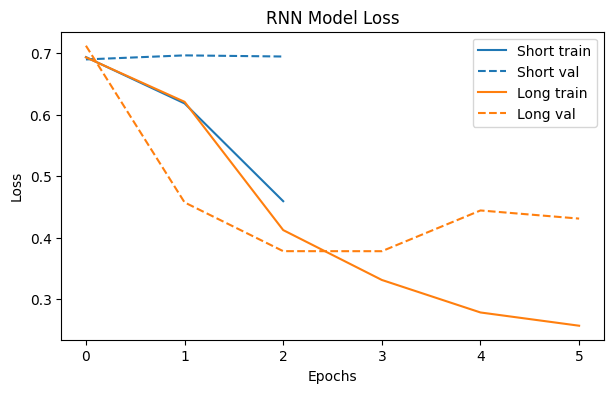

In [18]:
#Plot the loss curves from the recorded training history, no retraining needed
plot_loss({'Short': histories['RNN short'], 'Long': histories['RNN long']}, 'RNN Model Loss')

RNN short 0-100: 0.542 100-200: 0.518 200-300: 0.511 300-400: 0.510 400-500: 0.535 500+: 0.504
RNN long 0-100: 0.854 100-200: 0.846 200-300: 0.849 300-400: 0.838 400-500: 0.838 500+: 0.825
Samples per bucket: {'0-100': 3012, '100-200': 11720, '200-300': 4759, '300-400': 2325, '400-500': 1259, '500+': 1925}


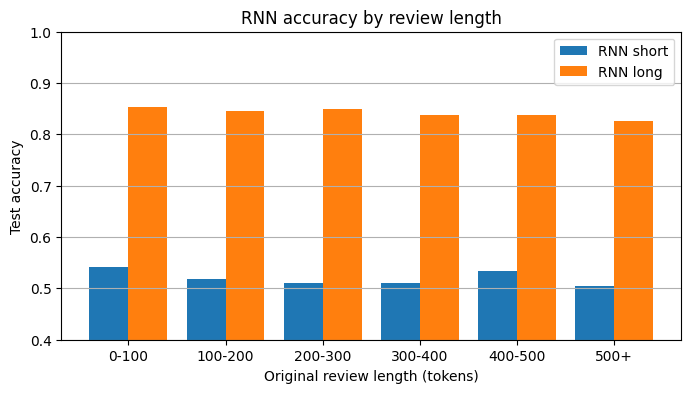

In [19]:
#RNN accuracy by review length
#Buckets by original length: 0-100 100-200 200-300 300-400 400-500 500+ (reviews over 500 are truncated)
length_bins = [100, 200, 300, 400, 500]
bin_labels = ['0-100', '100-200', '200-300', '300-400', '400-500', '500+']

def accuracy_by_length(model, X_padded, y, lengths):
    """Group by original length and return the accuracy and sample count of each bucket"""
    pred = (model.predict(X_padded, batch_size=256, verbose=0).ravel() > 0.5).astype(int)
    bucket = np.digitize(lengths, length_bins, right=True)
    accs, counts = [], []
    for b in range(len(bin_labels)):
        in_bucket = bucket == b
        counts.append(int(in_bucket.sum()))
        accs.append((pred[in_bucket] == y[in_bucket]).mean() if in_bucket.any() else np.nan)
    return np.array(accs), counts

def plot_accuracy_by_length(models, title):
    """Plot the per-bucket accuracy of several models in one chart"""
    plt.figure(figsize=(8, 4))
    width = 0.8 / len(models)
    x = np.arange(len(bin_labels))
    for i, (name, model) in enumerate(models.items()):
        accs, counts = accuracy_by_length(model, X_test_padded, y_test, test_lengths)
        plt.bar(x + i * width, accs, width, label=name)
        print(name, ' '.join(f'{l}: {a:.3f}' for l, a in zip(bin_labels, accs)))
    print('Samples per bucket:', dict(zip(bin_labels, counts)))
    plt.xticks(x + width * (len(models) - 1) / 2, bin_labels)
    plt.ylim(0.4, 1.0)
    plt.xlabel('Original review length (tokens)')
    plt.ylabel('Test accuracy')
    plt.title(title)
    plt.legend()
    plt.grid(axis='y')
    plt.show()

plot_accuracy_by_length({'RNN short': rnn_short_model, 'RNN long': rnn_long_model}, 'RNN accuracy by review length')

Permutation              RNN short    RNN long
Original                    0.5185      0.8446
Shuffle within 3            0.5174      0.8432
Shuffle within 10           0.5119      0.8414
Shuffle first half          0.5179      0.8409
Shuffle second half         0.5057      0.8376
Swap halves                 0.5034      0.8228
Reverse                     0.5104      0.8202
Full shuffle                0.5065      0.8331


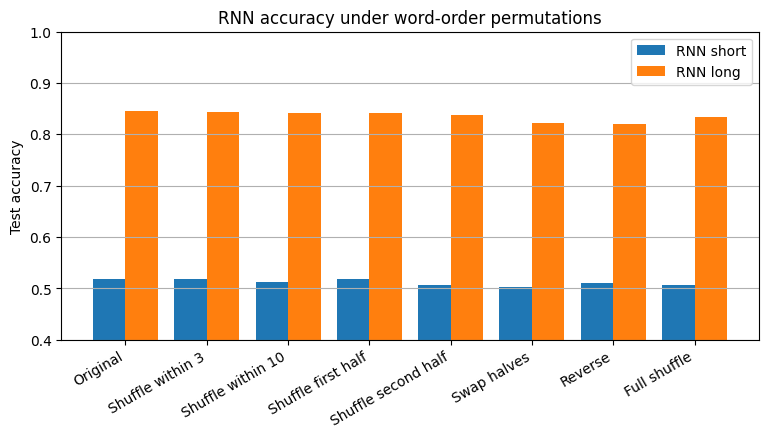

In [20]:
#Shuffle the word order in X_test for the RNN
#If accuracy drops, the model relies on the order of the input sequence (its memory)
#Every permutation keeps the leading <START> token, shuffles only the rest, then applies the same post padding as in training
rng = np.random.default_rng(42)

def shuffle_windows(tokens, window):
    """Shuffle only within fixed-size windows, keeping the large-scale order"""
    out = tokens.copy()
    for start in range(0, len(out), window):
        rng.shuffle(out[start:start + window])
    return out

def permute_half(tokens, which):
    """Shuffle only the first half or the second half"""
    out = tokens.copy()
    mid = len(out) // 2
    if which == 'first':
        rng.shuffle(out[:mid])
    else:
        rng.shuffle(out[mid:])
    return out

permutations = {
    'Original': lambda t: t,
    'Shuffle within 3': lambda t: shuffle_windows(t, 3),
    'Shuffle within 10': lambda t: shuffle_windows(t, 10),
    'Shuffle first half': lambda t: permute_half(t, 'first'),
    'Shuffle second half': lambda t: permute_half(t, 'second'),
    'Swap halves': lambda t: np.concatenate([t[len(t) // 2:], t[:len(t) // 2]]),
    'Reverse': lambda t: t[::-1],
    'Full shuffle': lambda t: rng.permutation(t),
}

def permutation_test(models):
    """Compute the test accuracy of each model under each permutation"""
    table = {name: [] for name in models}
    for perm_name, perm in permutations.items():
        X_perm = [np.concatenate([review[:1], perm(np.array(review[1:]))]) for review in X_test]
        X_perm_padded = pad_sequences(X_perm, maxlen=max_length, padding='post')
        for name, model in models.items():
            _, acc = model.evaluate(X_perm_padded, y_test, batch_size=256, verbose=0)
            table[name].append(acc)
    print(f"{'Permutation':<22}" + ''.join(f'{name:>12}' for name in models))
    for i, perm_name in enumerate(permutations):
        print(f'{perm_name:<22}' + ''.join(f'{table[name][i]:>12.4f}' for name in models))
    return table

perm_results = permutation_test({'RNN short': rnn_short_model, 'RNN long': rnn_long_model})

plt.figure(figsize=(9, 4))
x = np.arange(len(permutations))
for i, (name, accs) in enumerate(perm_results.items()):
    plt.bar(x + i * 0.4, accs, 0.4, label=name)
plt.xticks(x + 0.2, list(permutations), rotation=30, ha='right')
plt.ylim(0.4, 1.0)
plt.ylabel('Test accuracy')
plt.title('RNN accuracy under word-order permutations')
plt.legend()
plt.grid(axis='y')
plt.show()

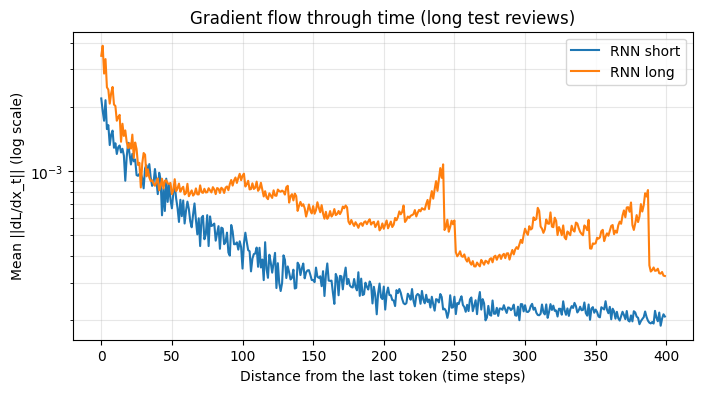

In [21]:
#Gradient analysis: measure the gradient of the loss with respect to the input (embedding) at each time step
#The x-axis is the distance from the last word of the review; a gradient that decays quickly with distance indicates vanishing gradients
def gradient_by_distance(model, n_samples=256, max_dist=400):
    idx = rng.choice(idx_test_long, size=min(n_samples, len(idx_test_long)), replace=False)
    x = tf.constant(X_test_padded[idx])
    y = tf.constant(y_test[idx].reshape(-1, 1), dtype=tf.float32)
    lengths = np.minimum(test_lengths[idx], max_length)
    emb_layer = model.layers[0]
    with tf.GradientTape() as tape:
        e = emb_layer(x)
        tape.watch(e)
        mask = emb_layer.compute_mask(x)
        h = e
        for layer in model.layers[1:]:
            h = layer(h, mask=mask) if isinstance(layer, layers.RNN) else layer(h)
        loss = tf.reduce_mean(keras.losses.binary_crossentropy(y, h))
    grad_norm = tf.norm(tape.gradient(loss, e), axis=-1).numpy()
    #Align every review by its distance from the end, then average
    sums, counts = np.zeros(max_dist), np.zeros(max_dist)
    for g, length in zip(grad_norm, lengths):
        k = min(length, max_dist)
        sums[:k] += g[length - 1::-1][:k]
        counts[:k] += 1
    return sums / np.maximum(counts, 1)

def plot_gradient_by_distance(models):
    plt.figure(figsize=(8, 4))
    for name, model in models.items():
        plt.semilogy(gradient_by_distance(model), label=name)
    plt.xlabel('Distance from the last token (time steps)')
    plt.ylabel('Mean ||dL/dx_t|| (log scale)')
    plt.title('Gradient flow through time (long test reviews)')
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)
    plt.show()

plot_gradient_by_distance({'RNN short': rnn_short_model, 'RNN long': rnn_long_model})

### RNN observations

- **RNN short does not reach the 70% target (test accuracy 51.9%, close to chance).** Its train loss falls to 0.46 while its val loss stays at 0.69, so it memorizes the 2,257 training reviews without generalizing. EarlyStopping then restores the epoch-1 weights. With this little data, a vanilla RNN overfits before it learns anything useful.
- **RNN long reaches 84.5%.** Its val loss is lowest (0.378) at epochs 2-3 and rises afterwards, which shows overfitting.
- **Review length has little effect on RNN long.** Accuracy goes from 85.4% (0-100 tokens) to 82.5% (500+ tokens). The 500+ bucket is the lowest, which fits with those reviews being truncated.
- **Word order matters little.** Shuffling within windows of 3 or 10 words costs less than 0.4 points, and a full shuffle costs only 1.2 points. So the model behaves mostly like a bag of words, and sentiment comes largely from individual words. Reversing the review (-2.4) or swapping its halves (-2.2) hurts more than a full shuffle. Shuffling the second half (-0.7) hurts more than shuffling the first half (-0.4). Together these suggest the model relies most on the end of the review.
- **The gradient decays with distance from the last token.** The last tokens get about 5-10x more gradient than tokens 100+ steps earlier, but the gradient does not collapse to zero within 400 steps, which fits with RNN long still reaching 84.5%. The sudden steps in the curve are an averaging artifact: at large distances, only the reviews that are at least that long contribute, so fewer reviews are averaged.

## GRU

The GRU uses a separate `Dropout` layer instead of `GRU(dropout=...)` so it can use cuDNN acceleration on the GPU.

In [22]:
#GRU: GRU(40) + Dense(1), about 8.9k parameters outside the Embedding
#The mask_zero=False variant is used by the padding experiments later
def create_gru_model(vocabulary_size, max_length, mask_zero=True):
    return keras.Sequential([
        keras.Input(shape=(max_length,)),
        layers.Embedding(vocabulary_size, EMBED_DIM, mask_zero=mask_zero),
        layers.GRU(40),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid'),
    ])

gru_short_model = create_gru_model(vocabulary_size, max_length)
gru_short_model.summary()
histories['GRU short'], results['GRU short'] = train_and_evaluate(
    'GRU short', gru_short_model, X_short_padded, y_short, X_test_padded, y_test, batch_size=128)

gru_long_model = create_gru_model(vocabulary_size, max_length)
histories['GRU long'], results['GRU long'] = train_and_evaluate(
    'GRU long', gru_long_model, X_long_padded, y_long, X_test_padded, y_test, batch_size=128)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 500, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 40)             │         8,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,921 (659.85 KB)

 Trainable params: 168,921 (659.85 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
18/18 - 3s - 183ms/step - accuracy: 0.5503 - loss: 0.6879 - val_accuracy: 0.5646 - val_loss: 0.6827
Epoch 2/8
18/18 - 0s - 16ms/step - accuracy: 0.5507 - loss: 0.6724 - val_accuracy: 0.5717 - val_loss: 0.6705
Epoch 3/8
18/18 - 0s - 17ms/step - accuracy: 0.6619 - loss: 0.6079 - val_accuracy: 0.7150 - val_loss: 0.5800
Epoch 4/8
18/18 - 0s - 16ms/step - accuracy: 0.8241 - loss: 0.4689 - val_accuracy: 0.7310 - val_loss: 0.5466
Epoch 5/8
18/18 - 0s - 16ms/step - accuracy: 0.8768 - loss: 0.3264 - val_accuracy: 0.8071 - val_loss: 0.4266
Epoch 6/8
18/18 - 0s - 15ms/step - accuracy: 0.9269 - loss: 0.2035 - val_accuracy: 0.8212 - val_loss: 0.3993
Epoch 7/8
18/18 - 0s - 15ms/step - accuracy: 0.9597 - loss: 0.1327 - val_accuracy: 0.8212 - val_loss: 0.5496
Epoch 8/8
18/18 - 0s - 16ms/step - accuracy: 0.9650 - loss: 0.1095 - val_accuracy: 0.8372 - val_loss: 0.3991
GRU short: test acc=0.7780, test loss=0.5420, params=8921 (K=10000), time=5.4s (0.7s/epoch)
Epoch 1/8
139/139 - 5s - 37ms/step 

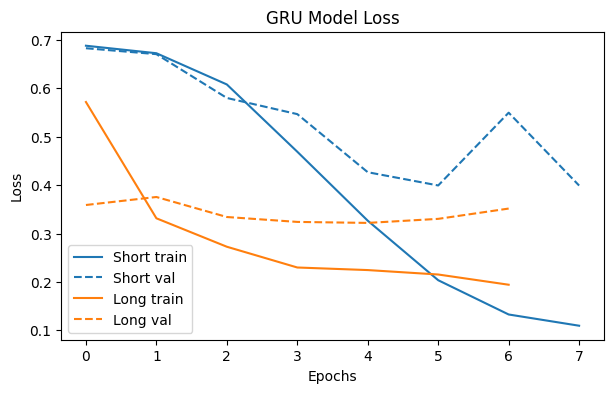

In [23]:
#Plot the GRU loss curves from the recorded training history
plot_loss({'Short': histories['GRU short'], 'Long': histories['GRU long']}, 'GRU Model Loss')

RNN long 0-100: 0.854 100-200: 0.846 200-300: 0.849 300-400: 0.838 400-500: 0.838 500+: 0.825
GRU short 0-100: 0.814 100-200: 0.786 200-300: 0.764 300-400: 0.770 400-500: 0.750 500+: 0.734
GRU long 0-100: 0.878 100-200: 0.876 200-300: 0.868 300-400: 0.865 400-500: 0.869 500+: 0.850
Samples per bucket: {'0-100': 3012, '100-200': 11720, '200-300': 4759, '300-400': 2325, '400-500': 1259, '500+': 1925}


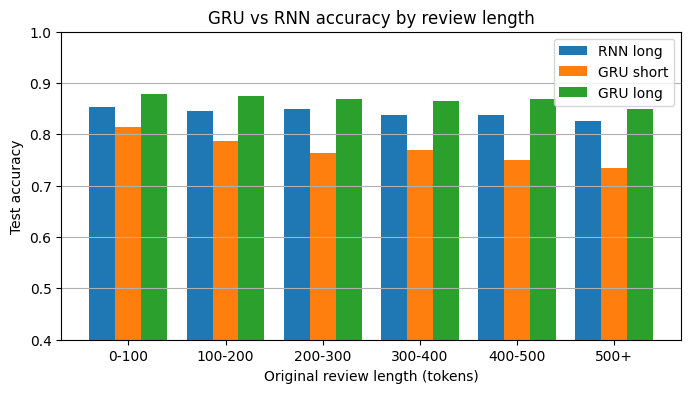

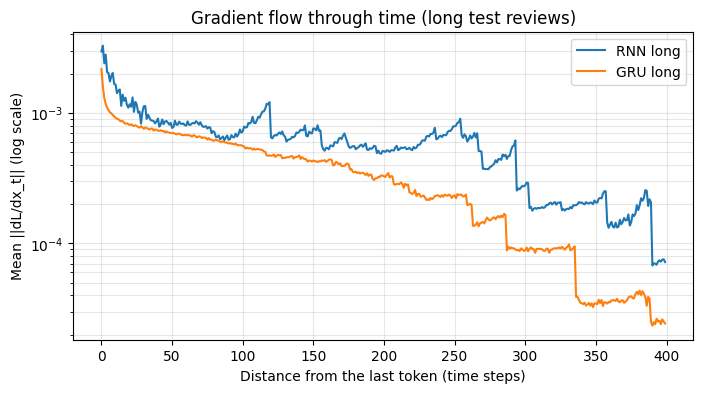

Permutation              GRU short    GRU long
Original                    0.7780      0.8714
Shuffle within 3            0.7772      0.8712
Shuffle within 10           0.7765      0.8700
Shuffle first half          0.7783      0.8710
Shuffle second half         0.7510      0.8635
Swap halves                 0.7179      0.8534
Reverse                     0.7127      0.8492
Full shuffle                0.7382      0.8616


In [24]:
#GRU accuracy by review length, compared with the RNN
#Buckets by original length: 0-100 100-200 200-300 300-400 400-500 500+
plot_accuracy_by_length({'RNN long': rnn_long_model, 'GRU short': gru_short_model, 'GRU long': gru_long_model},
                        'GRU vs RNN accuracy by review length')

#Compare gradient flow of the GRU and RNN, and the GRU's sensitivity to word-order permutations
plot_gradient_by_distance({'RNN long': rnn_long_model, 'GRU long': gru_long_model})
gru_perm_results = permutation_test({'GRU short': gru_short_model, 'GRU long': gru_long_model})

### GRU observations

- **GRU is the best recurrent model:** 77.8% trained on short reviews and 87.1% trained on long reviews.
- **GRU long is nearly flat across lengths,** from 87.8% (0-100 tokens) to 85.0% (500+ tokens).
- **GRU short degrades as reviews get longer,** from 81.4% on 0-100 tokens (its training distribution) to 73.4% on 500+ tokens. It has only seen reviews of up to 100 tokens and generalizes worse the further the input is from that.
- **GRU is more order-sensitive than RNN.** GRU short loses 6.5 points when the review is reversed, 6.0 when the halves are swapped, 4.0 with a full shuffle, and 2.7 when the second half is shuffled, but nothing when the first half is shuffled. GRU long shows the same pattern with smaller drops (reverse -2.2, full shuffle -1.0). Local shuffles barely matter for either model. So the GRU uses word order more than the RNN does, mostly at the end of the review.
- **GRU long's gradient decays more steeply than RNN long's,** by roughly an order of magnitude more over 400 steps. This measure (the gradient of the loss with respect to each input token) also drops when a model has *learned* to discount distant tokens, not only when gradients vanish. So it does not show the GRU having longer memory here. The GRU's advantage looks more like better use of recent context, which matches the permutation results.

In [25]:
#Compare GRU and LSTM performance
#LSTM(34) + Dense(1), about 9.1k parameters outside the Embedding, a budget comparable to GRU(40)
def create_lstm_model(vocabulary_size, max_length):
    return keras.Sequential([
        keras.Input(shape=(max_length,)),
        layers.Embedding(vocabulary_size, EMBED_DIM, mask_zero=True),
        layers.LSTM(34),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid'),
    ])

lstm_short_model = create_lstm_model(vocabulary_size, max_length)
histories['LSTM short'], results['LSTM short'] = train_and_evaluate(
    'LSTM short', lstm_short_model, X_short_padded, y_short, X_test_padded, y_test, batch_size=128)

lstm_long_model = create_lstm_model(vocabulary_size, max_length)
histories['LSTM long'], results['LSTM long'] = train_and_evaluate(
    'LSTM long', lstm_long_model, X_long_padded, y_long, X_test_padded, y_test, batch_size=128)

print(f"{'Model':<12}{'Units':>7}{'Params':>9}{'Acc':>9}{'s/epoch':>10}")
for name, units in [('GRU short', 40), ('LSTM short', 34), ('GRU long', 40), ('LSTM long', 34)]:
    r = results[name]
    print(f"{name:<12}{units:>7}{r['params']:>9}{r['accuracy']:>9.4f}{r['time_per_epoch']:>10.1f}")

Epoch 1/8
18/18 - 3s - 167ms/step - accuracy: 0.5481 - loss: 0.6881 - val_accuracy: 0.5646 - val_loss: 0.6803
Epoch 2/8
18/18 - 0s - 26ms/step - accuracy: 0.5512 - loss: 0.6624 - val_accuracy: 0.5770 - val_loss: 0.6217
Epoch 3/8
18/18 - 1s - 36ms/step - accuracy: 0.7528 - loss: 0.5510 - val_accuracy: 0.6265 - val_loss: 0.6259
Epoch 4/8
18/18 - 0s - 21ms/step - accuracy: 0.8245 - loss: 0.4941 - val_accuracy: 0.7540 - val_loss: 0.5151
Epoch 5/8
18/18 - 0s - 25ms/step - accuracy: 0.8711 - loss: 0.4026 - val_accuracy: 0.7947 - val_loss: 0.4893
Epoch 6/8
18/18 - 0s - 25ms/step - accuracy: 0.9034 - loss: 0.2933 - val_accuracy: 0.8372 - val_loss: 0.4148
Epoch 7/8
18/18 - 0s - 23ms/step - accuracy: 0.9322 - loss: 0.2329 - val_accuracy: 0.8442 - val_loss: 0.4102
Epoch 8/8
18/18 - 0s - 21ms/step - accuracy: 0.9548 - loss: 0.1651 - val_accuracy: 0.8442 - val_loss: 0.4212
LSTM short: test acc=0.7372, test loss=0.6506, params=9147 (K=10000), time=6.3s (0.8s/epoch)
Epoch 1/8
139/139 - 6s - 41ms/step

### GRU vs LSTM

- **With the same parameter budget, GRU is slightly better than LSTM:** 77.8% vs 73.7% on short reviews, and 87.1% vs 86.7% on long reviews. A GRU has 3 gate blocks instead of 4, so the same budget buys 40 GRU units vs 34 LSTM units.
- **Training speed is the same** (0.7 vs 0.8 s/epoch on short reviews, 4.1 vs 4.0 s/epoch on long reviews), because both use the cuDNN kernel.
- **LSTM long has the lowest test loss of all models (0.317),** so its predictions are slightly better calibrated even though its accuracy is lower.
- **Most differences come from a single seed.** Differences under about 1 point should not be over-interpreted.

Model         Params  Test acc  Test loss  Epochs  s/epoch  Total s
CNN short       8801    0.7773     0.4921       7      1.4      9.6
CNN long        8801    0.8597     0.3312       4      3.6     14.3
RNN short       9121    0.5185     0.6925       3      3.7     11.2
RNN long        9121    0.8446     0.3787       6      7.1     42.3
GRU short       8921    0.7780     0.5420       8      0.7      5.4
GRU long        8921    0.8714     0.3276       7      4.1     28.5
LSTM short      9147    0.7372     0.6506       8      0.8      6.3
LSTM long       9147    0.8667     0.3165       4      4.0     15.9


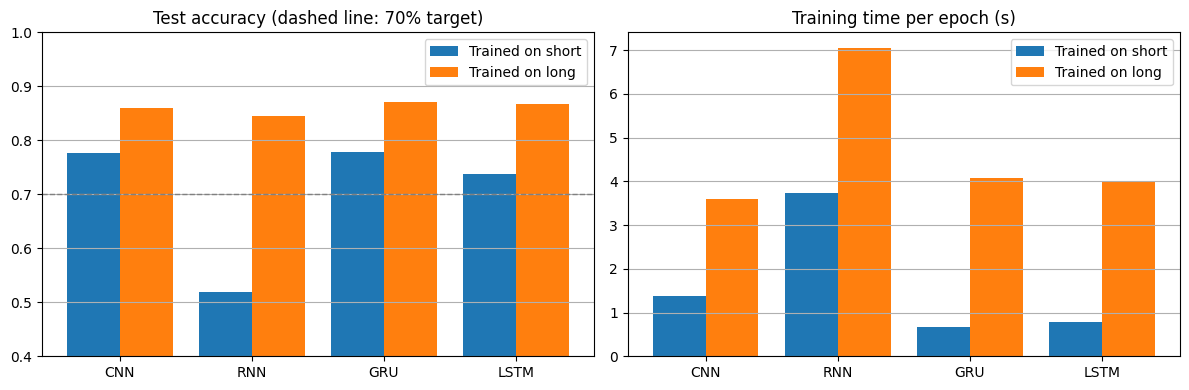

In [26]:
#Compare GRU performance with RNN and CNN
#Summarize test accuracy, loss, parameter count and training time of every model on the short and long datasets
print(f"{'Model':<12}{'Params':>8}{'Test acc':>10}{'Test loss':>11}{'Epochs':>8}{'s/epoch':>9}{'Total s':>9}")
for name, r in results.items():
    print(f"{name:<12}{r['params']:>8}{r['accuracy']:>10.4f}{r['loss']:>11.4f}{r['epochs']:>8}"
          f"{r['time_per_epoch']:>9.1f}{r['train_time']:>9.1f}")

architectures = ['CNN', 'RNN', 'GRU', 'LSTM']
x = np.arange(len(architectures))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, subset in enumerate(['short', 'long']):
    axes[0].bar(x + i * 0.4, [results[f'{a} {subset}']['accuracy'] for a in architectures], 0.4, label=f'Trained on {subset}')
    axes[1].bar(x + i * 0.4, [results[f'{a} {subset}']['time_per_epoch'] for a in architectures], 0.4, label=f'Trained on {subset}')
axes[0].set_ylim(0.4, 1.0)
axes[0].axhline(0.7, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Test accuracy (dashed line: 70% target)')
axes[1].set_title('Training time per epoch (s)')
for ax in axes:
    ax.set_xticks(x + 0.2)
    ax.set_xticklabels(architectures)
    ax.grid(axis='y')
    ax.legend()
plt.tight_layout()
plt.show()

### Architecture comparison

| Trained on | Best | Accuracy ranking |
|---|---|---|
| Short reviews | GRU 77.8% | GRU 77.8 = CNN 77.7 > LSTM 73.7 > RNN 51.9 |
| Long reviews | GRU 87.1% | GRU 87.1 > LSTM 86.7 > CNN 86.0 > RNN 84.5 |

- **The CNN is competitive.** It is within about 1 point of the best recurrent model on long reviews. On short reviews it ties the GRU in accuracy with a lower test loss (0.49 vs 0.54). Given how little word order matters (see the permutation tests), a model that detects local n-gram features does nearly as well.
- **The RNN is the slowest (7.1 s/epoch on long reviews vs about 4 s for GRU/LSTM),** because SimpleRNN has no cuDNN kernel. It is also the least accurate.
- **The large baseline CNN (610k parameters, full dataset) reaches 85.8%, no better than the 8.8k-parameter CNN (86.0%).** It overfits from the first epoch: its val accuracy peaks at 89.1% after epoch 1 and then declines. A model about 70x larger buys nothing here.
- **Training on long reviews beats training on short reviews for every architecture.** The long subset has about 8x more data (22,178 vs 2,822 reviews) and matches the test set, which is 88% long reviews.

## Further Experimentation: Padding

Both experiments below train a GRU on short reviews only and evaluate it on the short test reviews.
The GRU here uses `mask_zero=False`; with masking the model would simply ignore the padding, hiding the effect of the padding strategy.

In [27]:
#Custom padding function: supports pre / post / center positions, and a constant or random 0/1 padding value
#Sequences that are too long keep their last part, like the pad_sequences default
def pad_custom(sequences, maxlen, position='post', value=0, seed=42):
    pad_rng = np.random.default_rng(seed)
    out = np.zeros((len(sequences), maxlen), dtype='int32')
    for i, seq in enumerate(sequences):
        seq = np.asarray(seq[-maxlen:])
        n_pad = maxlen - len(seq)
        pad = pad_rng.integers(0, 2, size=n_pad) if value == 'random' else np.full(n_pad, value)
        if position == 'post':
            out[i] = np.concatenate([seq, pad])
        elif position == 'pre':
            out[i] = np.concatenate([pad, seq])
        else:
            left = n_pad // 2
            out[i] = np.concatenate([pad[:left], seq, pad[left:]])
    return out

X_test_short = [X_test[i] for i in idx_test_short]
y_test_short = y_test[idx_test_short]

def run_padding_experiment(configs, title):
    """configs: {name: (position, value)}; each setting trains a GRU from the same random seed"""
    exp_results, exp_histories = {}, {}
    for name, (position, value) in configs.items():
        keras.utils.set_random_seed(42)
        X_tr = pad_custom(X_short, max_length, position, value)
        X_te = pad_custom(X_test_short, max_length, position, value)
        model = create_gru_model(vocabulary_size, max_length, mask_zero=False)
        exp_histories[name], exp_results[name] = train_and_evaluate(
            f'GRU {name}', model, X_tr, y_short, X_te, y_test_short, batch_size=128)

    names = list(configs)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for name in names:
        axes[0].plot(exp_histories[name].history['val_loss'], marker='o', label=name)
    axes[0].set_title('Validation loss')
    axes[0].set_xlabel('Epochs')
    axes[0].legend()
    axes[1].bar(names, [exp_results[n]['accuracy'] for n in names], color='salmon')
    axes[1].set_ylim(0.4, 1.0)
    axes[1].set_title('Test accuracy (short reviews)')
    axes[2].bar(names, [exp_results[n]['time_per_epoch'] for n in names], color='skyblue')
    axes[2].set_title('Training time per epoch (s)')
    for ax in axes:
        ax.grid(axis='y')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    return exp_results, exp_histories

Epoch 1/8
18/18 - 2s - 121ms/step - accuracy: 0.5481 - loss: 0.6883 - val_accuracy: 0.5646 - val_loss: 0.6827
Epoch 2/8
18/18 - 1s - 37ms/step - accuracy: 0.5498 - loss: 0.6753 - val_accuracy: 0.5681 - val_loss: 0.6711
Epoch 3/8
18/18 - 1s - 70ms/step - accuracy: 0.6433 - loss: 0.6111 - val_accuracy: 0.6796 - val_loss: 0.6279
Epoch 4/8
18/18 - 0s - 26ms/step - accuracy: 0.8290 - loss: 0.4498 - val_accuracy: 0.7504 - val_loss: 0.5167
Epoch 5/8
18/18 - 0s - 25ms/step - accuracy: 0.8937 - loss: 0.2988 - val_accuracy: 0.8018 - val_loss: 0.4363
Epoch 6/8
18/18 - 0s - 26ms/step - accuracy: 0.8866 - loss: 0.2920 - val_accuracy: 0.7469 - val_loss: 0.5324
Epoch 7/8
18/18 - 0s - 25ms/step - accuracy: 0.9198 - loss: 0.2198 - val_accuracy: 0.8088 - val_loss: 0.4512
GRU pre: test acc=0.7829, test loss=0.4496, params=8921 (K=10000), time=6.0s (0.9s/epoch)
Epoch 1/8
18/18 - 2s - 114ms/step - accuracy: 0.5454 - loss: 0.6888 - val_accuracy: 0.5646 - val_loss: 0.6849
Epoch 2/8
18/18 - 0s - 26ms/step - a

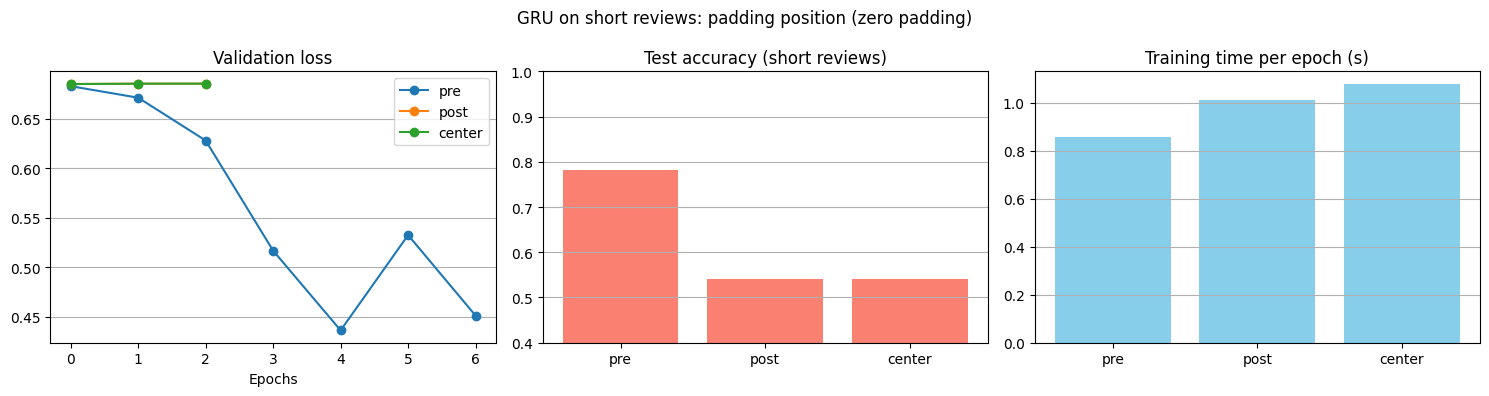

In [28]:
#Further Experimentation
#For the GRU model, use
#different padding positions: pre-padding, post-padding and centered padding
#Evaluation metrics
#validation loss
#accuracy
#training time
#efficiency
#Experiments on short reviews only, all with zero padding
position_results, position_histories = run_padding_experiment(
    {'pre': ('pre', 0), 'post': ('post', 0), 'center': ('center', 0)},
    'GRU on short reviews: padding position (zero padding)')

### Padding position observations

- **Only pre-padding learns (78.3%).** Post- and centered padding both stay at 54.05% and effectively predict the same class for every review: val accuracy is fixed at 0.5646 in every epoch, and EarlyStopping ends training after 3 epochs.
- **Why:** each short review (at most 100 tokens) is padded to 500 tokens, and this GRU is not masked. With post-padding, at least 400 padding steps separate the last real word from the output. The review's signal has to survive all of those steps, and the model never picks it up. Centered padding still leaves at least 200 steps and also fails. Pre-padding puts the content right next to the output.
- **This contradicts the claim in section 3.3 of the spec** that post-padding is better for recurrent models. For a model that classifies from its final hidden state, what matters is how far the content is from the output, and post-padding puts it as far away as possible. Post-padding only works well when the padding is masked, as in the main models above.
- **Training time per epoch is the same for all three (0.9-1.1 s),** since the sequence length is always 500.
- **Caveat:** EarlyStopping with patience 2 may have stopped the post/center runs before they could escape the plateau. With more epochs they might eventually learn.

Epoch 1/8
18/18 - 2s - 114ms/step - accuracy: 0.5454 - loss: 0.6888 - val_accuracy: 0.5646 - val_loss: 0.6849
Epoch 2/8
18/18 - 0s - 26ms/step - accuracy: 0.5494 - loss: 0.6888 - val_accuracy: 0.5646 - val_loss: 0.6852
Epoch 3/8
18/18 - 0s - 25ms/step - accuracy: 0.5494 - loss: 0.6884 - val_accuracy: 0.5646 - val_loss: 0.6852
GRU zero: test acc=0.5405, test loss=0.6905, params=8921 (K=10000), time=3.0s (1.0s/epoch)
Epoch 1/8
18/18 - 2s - 104ms/step - accuracy: 0.5485 - loss: 0.6888 - val_accuracy: 0.5646 - val_loss: 0.6849
Epoch 2/8
18/18 - 1s - 30ms/step - accuracy: 0.5494 - loss: 0.6889 - val_accuracy: 0.5646 - val_loss: 0.6853
Epoch 3/8
18/18 - 1s - 34ms/step - accuracy: 0.5494 - loss: 0.6885 - val_accuracy: 0.5646 - val_loss: 0.6852
GRU one: test acc=0.5405, test loss=0.6905, params=8921 (K=10000), time=3.1s (1.0s/epoch)
Epoch 1/8
18/18 - 2s - 114ms/step - accuracy: 0.5467 - loss: 0.6889 - val_accuracy: 0.5646 - val_loss: 0.6846
Epoch 2/8
18/18 - 1s - 58ms/step - accuracy: 0.5494 -

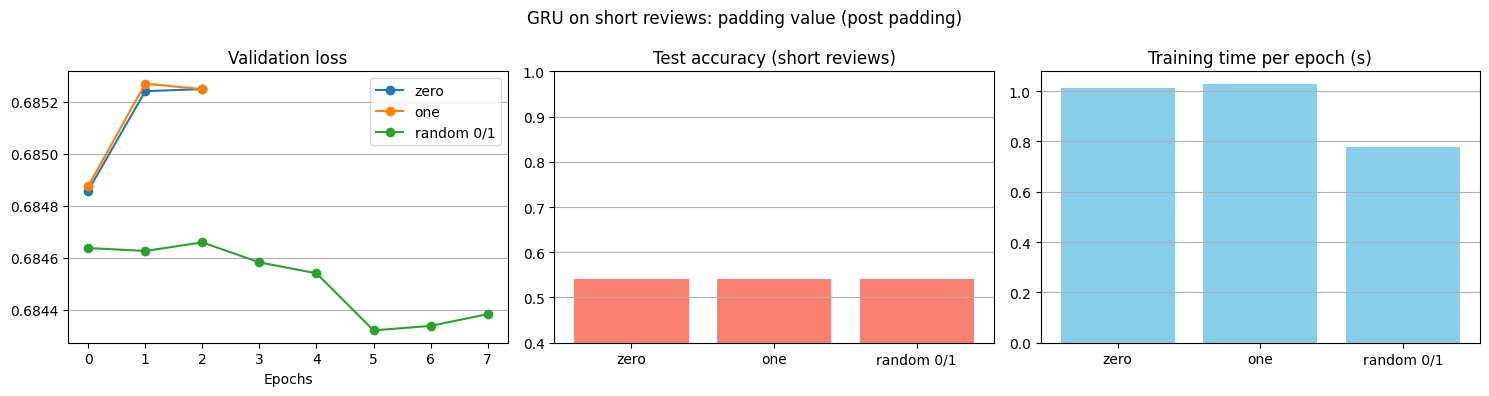

In [29]:
#Further Experimentation
#For the GRU model, use
#different padding values: 0, 1 and random
#Evaluation metrics
#validation loss
#accuracy
#training time
#efficiency
#Experiments on short reviews only, all with post padding
#Note: in this dataset 1 is the <START> token, so padding with 1 appends a run of <START> tokens to the review
value_results, value_histories = run_padding_experiment(
    {'zero': ('post', 0), 'one': ('post', 1), 'random 0/1': ('post', 'random')},
    'GRU on short reviews: padding value (post padding)')

### Padding value observations

- **All three padding values (0, 1, random 0/1) give the same result (54.05%).** This is the same failure as post-padding above, so this experiment is **inconclusive**. With post-padding the model never learns, so the padding value cannot make a difference. To isolate the effect of the padding value, the experiment should be rerun with pre-padding.
- **The "zero" run exactly reproduces the "post" run from the previous experiment** (same seed, same setting), which confirms the runs are reproducible.

## Conclusions

1. **All models except RNN short reach the 70% target.** RNN short (51.9%) overfits the 2,822 short reviews.
2. **GRU is the best architecture overall** (87.1% on long reviews). LSTM (86.7%) and CNN (86.0%) are close behind with the same parameter budget.
3. **Sentiment in IMDB is carried mostly by individual words.** Shuffling words locally barely changes accuracy, and even a full shuffle costs only 1-4 points. This explains why a CNN does nearly as well as the recurrent models.
4. **The recurrent models rely most on the end of the review.** They are most hurt by permutations that move the last part of the review, and their input gradients decay with distance from the last token.
5. **Where the padding sits relative to the output is decisive for an unmasked GRU.** Pre-padding works (78.3%), while post- and centered padding fail completely (54%). This is the opposite of what the spec suggests. Masking (`mask_zero=True`) removes the problem entirely.
6. **Training on more data beats matching the length distribution.** For the GRU and the RNN, the models trained on long reviews are better on every length bucket, even on 0-100-token reviews (GRU: 87.8% vs 81.4%). Per-bucket accuracy was not computed for the CNN and LSTM.